# Análisis Estadístico de Precipitaciones y Factores Climáticos en la Región Junín (Jauja)
El objetivo es identificar patrones estacionales y horas críticas de precipitación para la planificación de actividades exteriores o infraestructura.

In [ ]:
# 1. INSTALACIÓN DE LIBRERÍAS
!pip install openmeteo-requests requests-cache retry-requests

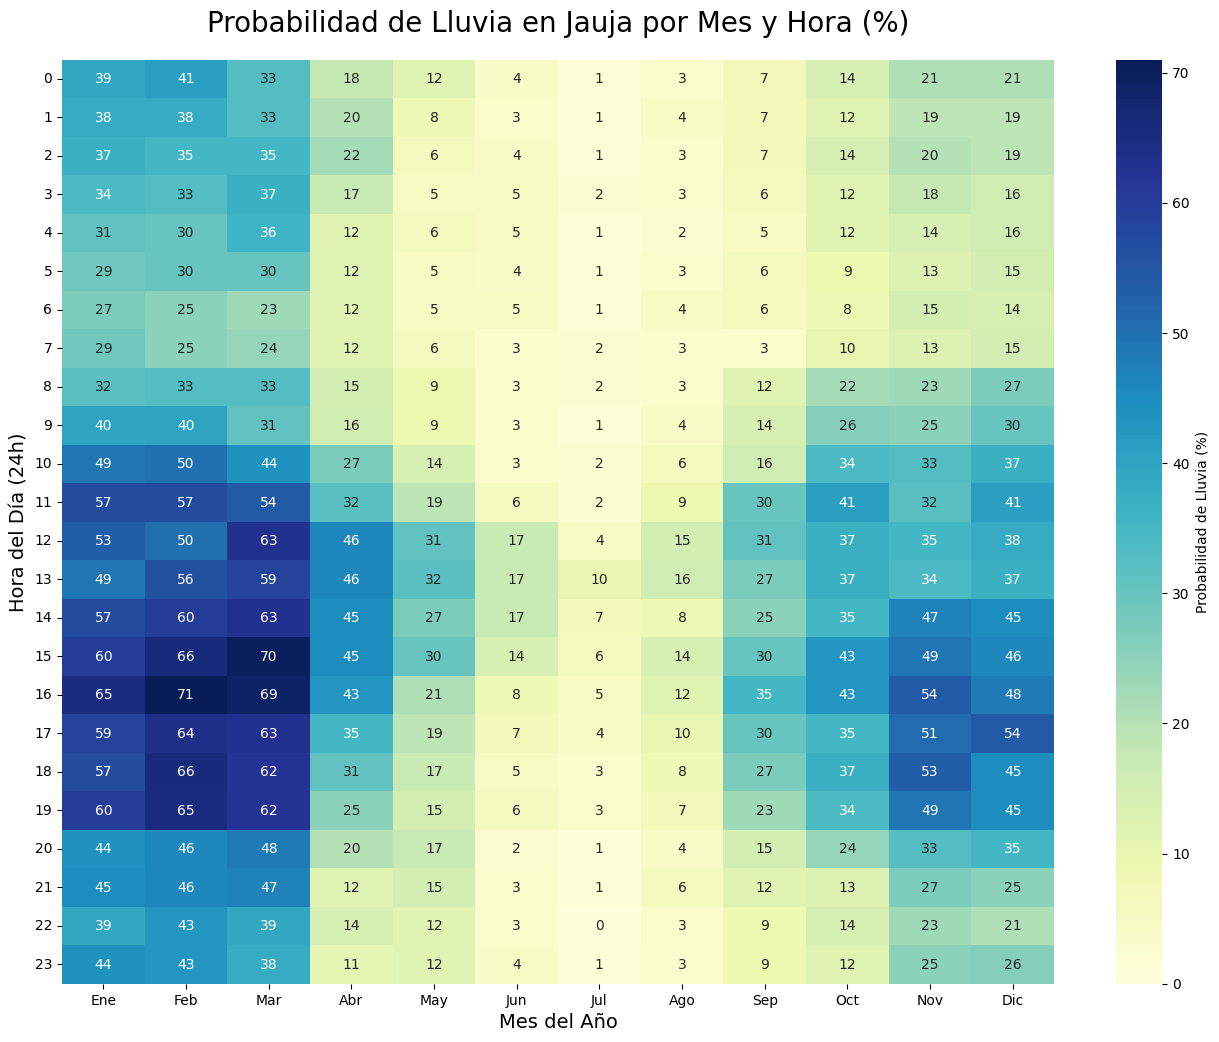

In [8]:
# 2. IMPORTACIÓN DE MÓDULOS
import openmeteo_requests
import requests_cache
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from retry_requests import retry

# 3. CONFIGURACIÓN DEL CLIENTE API
# Configuramos la caché para no saturar la API
cache_session = requests_cache.CachedSession('.cache', expire_after=-1)
# Configuramos los reintentos directamente sobre la sesión para mayor robustez
retry_session = retry(cache_session, retries=5, backoff_factor=0.2)
openmeteo = openmeteo_requests.Client(session=retry_session)

# 4. EXTRACCIÓN DE DATOS - CASO DE ESTUDIO: JAUJA, PERÚ (Cambio de ubicación)
url = "https://archive-api.open-meteo.com/v1/archive"
params = {
    "latitude": -11.7758,   # Coordenadas de Jauja
    "longitude": -75.4965,
    "start_date": "2021-01-01",
    "end_date": "2026-03-31",
    "hourly": ["precipitation"], # Solo necesitamos la precipitación para la probabilidad
    "timezone": "America/Lima"
}

# Realizamos la petición
responses = openmeteo.weather_api(url, params=params)
response = responses[0]

# Procesamos los datos horarios
hourly = response.Hourly()
data = {
    "fecha": pd.date_range(
        start=pd.to_datetime(hourly.Time(), unit="s", utc=True),
        end=pd.to_datetime(hourly.TimeEnd(), unit="s", utc=True),
        freq=pd.Timedelta(seconds=hourly.Interval()),
        inclusive="left"
    ),
    "precipitacion": hourly.Variables(0).ValuesAsNumpy(),
}

# Crear DataFrame y ajustar zona horaria
df = pd.DataFrame(data)
df['fecha'] = df['fecha'].dt.tz_convert('America/Lima')
df['mes'] = df['fecha'].dt.month
df['hora'] = df['fecha'].dt.hour

# ---------------------------------------------------------------------------------
# NUEVO CÁLCULO: PROBABILIDAD DE LLUVIA (Para imitar el gráfico original)
# ---------------------------------------------------------------------------------
# Creamos una columna booleana que indica si llovió (más de 0mm)
df['es_lluvia'] = df['precipitacion'] > 0

# Creamos la tabla pivote intercambiando los ejes y calculando el promedio de la booleana
# Aggfunc=mean de una booleana nos da la frecuencia (probabilidad)
heatmap_data = df.pivot_table(
    index='hora',      # HORAS EN EL EJE Y (Invertido respecto al script anterior)
    columns='mes',     # MESES EN EL EJE X
    values='es_lluvia', # Usamos la nueva columna
    aggfunc='mean'
)

# Convertimos la probabilidad a porcentaje (multiplicamos por 100) y redondeamos a entero
heatmap_data = (heatmap_data * 100).round(0).astype(int)

# Reemplazamos los números de los meses por sus nombres
nombres_meses = {
    1: 'Ene', 2: 'Feb', 3: 'Mar', 4: 'Abr', 5: 'May', 6: 'Jun',
    7: 'Jul', 8: 'Ago', 9: 'Sep', 10: 'Oct', 11: 'Nov', 12: 'Dic'
}
heatmap_data.columns = heatmap_data.columns.map(nombres_meses)

# ---------------------------------------------------------------------------------
# VISUALIZACIÓN PROFESIONAL (Idéntica al original de Huancayo)
# ---------------------------------------------------------------------------------
# Ajustamos el tamaño de la figura para que quepa bien la matriz de 24x12 con números
plt.figure(figsize=(16, 12))

# Configuración estética del gráfico
sns.heatmap(
    heatmap_data,
    cmap="YlGnBu",     # Mismo mapa de colores que el original
    annot=True,        # ¡AÑADIMOS LAS ANOTACIONES NUMÉRICAS!
    fmt="d",           # Formato de números enteros
    cbar_kws={'label': 'Probabilidad de Lluvia (%)'} # Etiqueta de la barra de color
)

# Personalización total de etiquetas y títulos para que coincidan
plt.title('Probabilidad de Lluvia en Jauja por Mes y Hora (%)', fontsize=20, pad=20)
plt.xlabel('Mes del Año', fontsize=14)
plt.ylabel('Hora del Día (24h)', fontsize=14)

# Aseguramos que las horas y meses se lean recto
plt.xticks(rotation=0)
plt.yticks(rotation=0)

plt.show()

# Mapa de Disponibilidad Operativa
Divide el análisis por meses específicos y usa cuadraditos de colores (blanco, amarillo, naranja y rojo) para mostrar el nivel de riesgo de lluvia día por día y hora por hora.

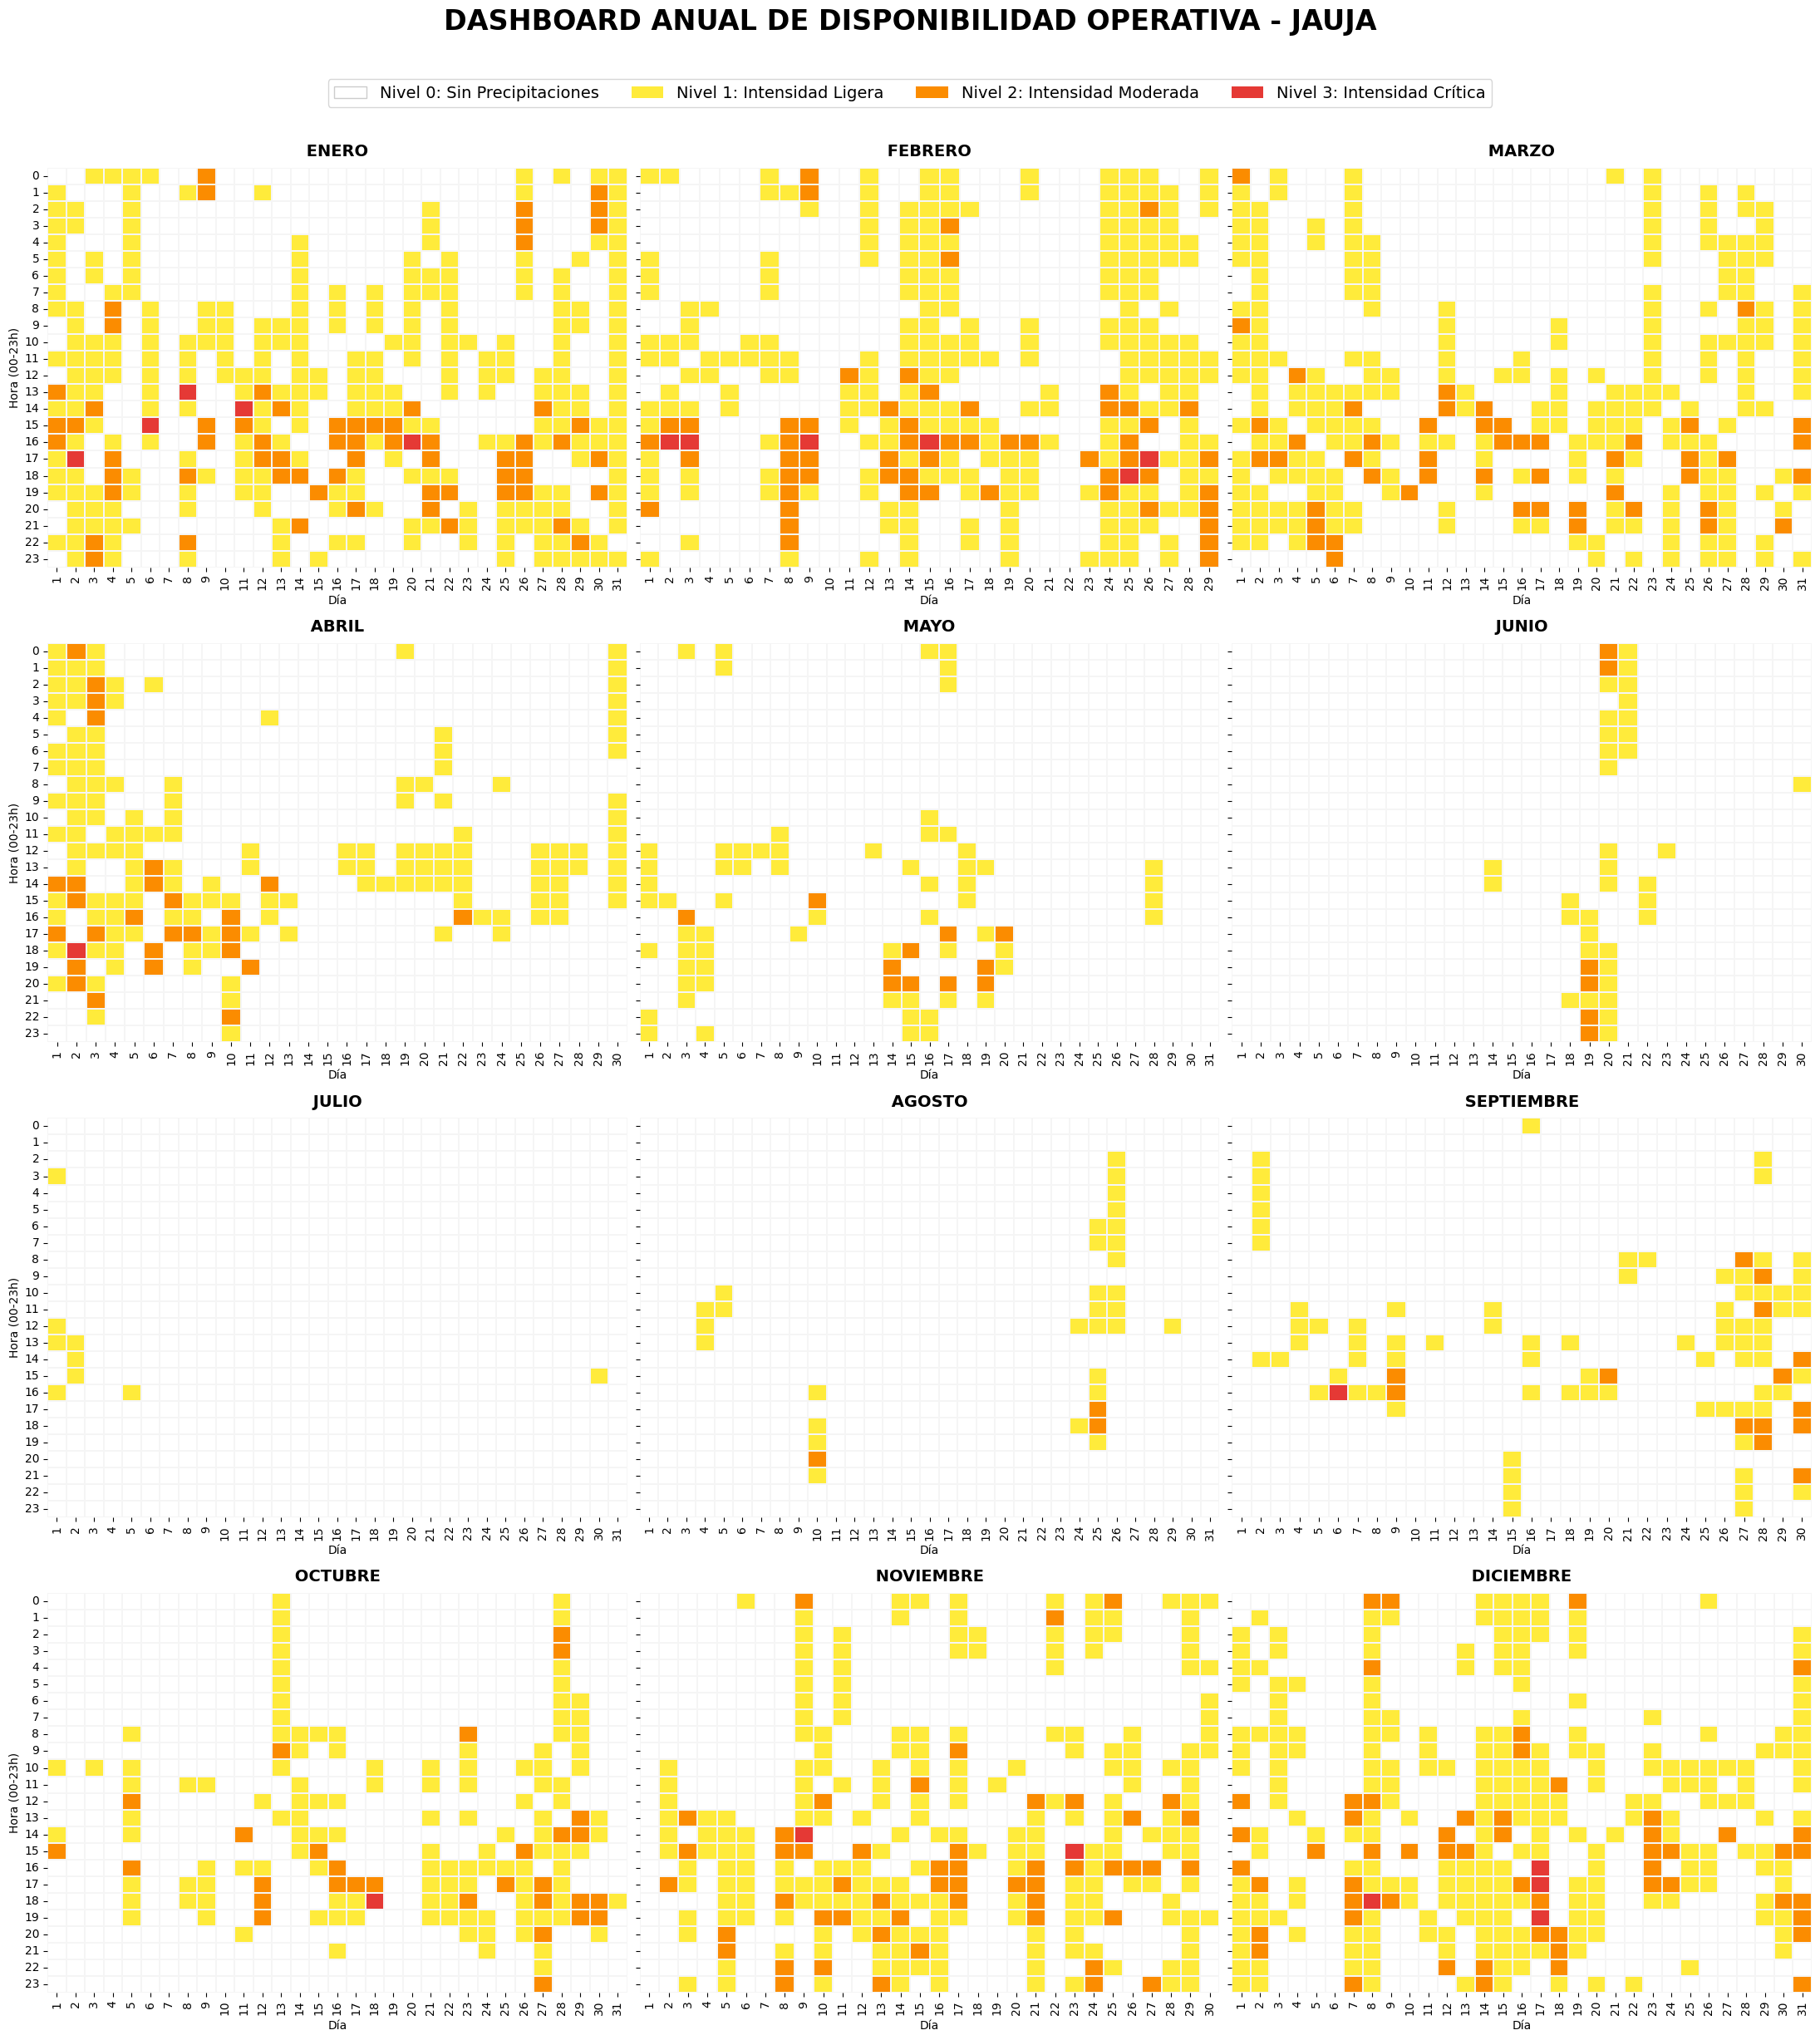

In [12]:
import openmeteo_requests
import requests_cache
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import ListedColormap
from retry_requests import retry

# 1. CONFIGURACIÓN DE API - AÑO COMPLETO 2024
cache_session = requests_cache.CachedSession('.cache', expire_after=-1)
retry_session = retry(cache_session, retries=5)
openmeteo = openmeteo_requests.Client(session=retry_session)

url = "https://archive-api.open-meteo.com/v1/archive"
params = {
    "latitude": -11.7758,
    "longitude": -75.4965,
    "start_date": "2024-01-01",
    "end_date": "2024-12-31", # Año completo
    "hourly": ["precipitation"],
    "timezone": "America/Lima"
}

responses = openmeteo.weather_api(url, params=params)
response = responses[0]
hourly = response.Hourly()

# 2. PROCESAMIENTO
df = pd.DataFrame({
    "fecha": pd.date_range(
        start=pd.to_datetime(hourly.Time(), unit="s", utc=True),
        end=pd.to_datetime(hourly.TimeEnd(), unit="s", utc=True),
        freq=pd.Timedelta(seconds=hourly.Interval()),
        inclusive="left"
    ),
    "precipitacion": hourly.Variables(0).ValuesAsNumpy(),
})

df['fecha'] = df['fecha'].dt.tz_convert('America/Lima')
df['mes'] = df['fecha'].dt.month
df['dia'] = df['fecha'].dt.day
df['hora'] = df['fecha'].dt.hour

def clasificar_nivel(p):
    if p == 0: return 0
    elif p < 1: return 1
    elif p < 5: return 2
    else: return 3

df['nivel'] = df['precipitacion'].apply(clasificar_nivel)

# 3. CONFIGURACIÓN DEL GRÁFICO (4 filas x 3 columnas = 12 meses)
fig, axes = plt.subplots(4, 3, figsize=(22, 25), sharey=True)
axes = axes.flatten() # Aplanamos la matriz para iterar fácilmente

meses_nombres = {
    1: "ENERO", 2: "FEBRERO", 3: "MARZO", 4: "ABRIL",
    5: "MAYO", 6: "JUNIO", 7: "JULIO", 8: "AGOSTO",
    9: "SEPTIEMBRE", 10: "OCTUBRE", 11: "NOVIEMBRE", 12: "DICIEMBRE"
}

# Colores originales: Blanco (Seco), Amarillo (Ligero), Naranja (Medio), Rojo (Fuerte)
colores = ['#FFFFFF', '#FFEB3B', '#FB8C00', '#E53935']
my_cmap = ListedColormap(colores)

for i, mes in enumerate(range(1, 13)):
    df_mes = df[df['mes'] == mes]
    pivot_mes = df_mes.pivot_table(index='hora', columns='dia', values='nivel')

    sns.heatmap(pivot_mes, ax=axes[i], cmap=my_cmap, cbar=False,
                linewidths=0.1, linecolor='#F5F5F5', vmin=0, vmax=3)

    axes[i].set_title(f" {meses_nombres[mes]} ", fontsize=14, fontweight='bold', pad=10)
    axes[i].set_xlabel("Día")
    if i % 3 == 0: axes[i].set_ylabel("Hora (00-23h)")
    else: axes[i].set_ylabel("")

# 4. LEYENDA Y TÍTULOS
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#FFFFFF', edgecolor='#CCCCCC', label='Nivel 0: Sin Precipitaciones'),
    Patch(facecolor='#FFEB3B', label='Nivel 1: Intensidad Ligera'),
    Patch(facecolor='#FB8C00', label='Nivel 2: Intensidad Moderada'),
    Patch(facecolor='#E53935', label='Nivel 3: Intensidad Crítica')
]
fig.legend(handles=legend_elements, loc='upper center', ncol=4, bbox_to_anchor=(0.5, 0.98), fontsize=14)

plt.suptitle("DASHBOARD ANUAL DE DISPONIBILIDAD OPERATIVA - JAUJA", fontsize=24, y=1.01, fontweight='bold')
plt.tight_layout(rect=[0, 0.03, 1, 0.97])

# Guardar la imagen para el portafolio
plt.savefig('dashboard_clima_jauja_completo.png', dpi=300, bbox_inches='tight')
plt.show()

In [13]:
# =================================================================
# EXPORTACIÓN DE DATOS A CSV
# =================================================================
from google.colab import files

# Nombre del archivo profesional para tu portafolio
file_name = "datos_meteorologicos_jauja_2024.csv"

# Guardamos el DataFrame en un CSV (usamos index=False para que no cree una columna extra)
df.to_csv(file_name, index=False, encoding='utf-8-sig')

# Iniciamos la descarga en tu navegador
files.download(file_name)

print(f"✅ El archivo '{file_name}' se ha generado y la descarga ha comenzado.")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ El archivo 'datos_meteorologicos_jauja_2024.csv' se ha generado y la descarga ha comenzado.
